In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Larter-Breakspear Model

The **Larter-Breakspear model** is a conductance-based mean-field model derived from the Morris-Lecar equations, with mean membrane potential $V$, a potassium gating variable $W$, and an inhibitory variable $Z$. Voltage-gated Na$^+$, K$^+$ and Ca$^{2+}$ currents make it capable of fixed points, limit cycles, and chaos depending on parameters. The pyramidal firing-threshold variance $d_V$ is a particularly effective knob for selecting the dynamical regime.

**Reference:** Breakspear, Terry & Friston (2003), *Modulation of excitatory synaptic coupling facilitates synchronization and complex dynamics in a biophysical model of neuronal dynamics*, Network: Computation in Neural Systems 14(4):703-732.

## Build the model

We pick `d_V = 0.57`, which puts the node in a limit-cycle band.

In [2]:
node = brainmass.LarterBreakspearStep(in_size=1, d_V=0.57)
node

LarterBreakspearStep(
  in_size=(1,),
  out_size=(1,),
  gCa=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(1.1, dtype=float32)
  ),
  gK=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(2., dtype=float32)
  ),
  gL=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.5, dtype=float32)
  ),
  gNa=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(6.7, dtype=float32)
  ),
  TCa=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(-0.01, dtype=float32)
  ),
  TK=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0., dtype=float32)
  ),
  TNa=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.3, dtype=float32)
  ),
  d_Ca=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.15, dtype=float32)
  ),
  d_K=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.3, dtype=float32)
  ),
  d_Na=Const(
    fit=False,
    t=IdentityT()

## Run a simulation

In [3]:
sim = brainmass.Simulator(node, dt=0.1 * u.ms)
res = sim.run(500. * u.ms, monitors=['V', 'W'], transient=100. * u.ms)
res['V'].shape

(4000, 1)

## Visualize

The mean potential `V` oscillates; the `V`-`W` phase portrait shows the conductance-based limit cycle.

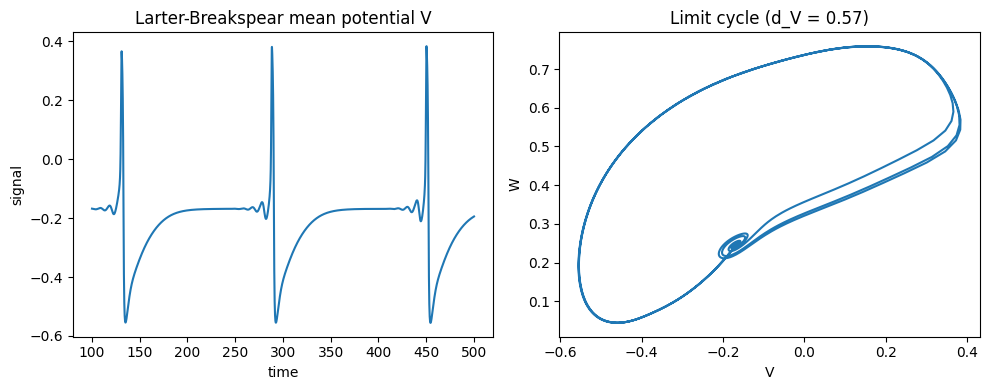

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
brainmass.viz.plot_timeseries(res['V'], ts=res['ts'], ax=axes[0])
axes[0].set_title('Larter-Breakspear mean potential V')
brainmass.viz.plot_phase_portrait(res['V'], res['W'], ax=axes[1])
axes[1].set_xlabel('V'); axes[1].set_ylabel('W')
axes[1].set_title('Limit cycle (d_V = 0.57)')
plt.tight_layout()
plt.show()

## Try it: vary the threshold variance `d_V`

The regime boundaries are sharp. `d_V = 0.65` (default) gives a fixed point; `d_V = 0.57` gives a limit cycle. We report the steady-state standard deviation of `V` as a simple oscillation detector.

In [5]:
for d_V in [0.50, 0.57, 0.65]:
    m = brainmass.LarterBreakspearStep(in_size=1, d_V=d_V)
    r = brainmass.Simulator(m, dt=0.1 * u.ms).run(
        500. * u.ms, monitors=['V'], transient=200. * u.ms)
    std = float(np.std(u.get_magnitude(r['V'])))
    regime = 'oscillatory' if std > 1e-3 else 'fixed point'
    print(f'd_V = {d_V:.2f}  ->  std(V) = {std:.3e}  ({regime})')

d_V = 0.50  ->  std(V) = 2.363e-06  (fixed point)
d_V = 0.57  ->  std(V) = 1.110e-01  (oscillatory)


d_V = 0.65  ->  std(V) = 1.307e-01  (oscillatory)
